In [ ]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Graph display settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully. Ready to load data")

✅ Libraries imported successfully. Ready to load data


In [ ]:
# Step 2: Load the dataset - Correct Path
df = pd.read_csv('sample_data/Sample - Superstore.csv', encoding='latin1')

print("Dataset Shape:", df.shape)  # Expected: (9994, 21)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (9994, 21)

First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Step 3: Check data information and quality
print("Column Names:\n", df.columns.tolist())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values Check ---")
df.isnull().sum()

Column Names:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
# Step 4: Data Cleaning
# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create new columns for analysis
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Year'] = df['Order Date'].dt.to_period('M')

# Check for negative values in Sales or Profit
print("Negative Sales Count:", (df['Sales'] < 0).sum())
print("Negative Profit Count:", (df['Profit'] < 0).sum()) # Negative profit is okay, loss

print("\n✅ Data Cleaning Done. New columns added: Year, Month, Month_Year")
df.head()

Negative Sales Count: 0
Negative Profit Count: 1871

✅ Data Cleaning Done. New columns added: Year, Month, Month_Year


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month_Year
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10


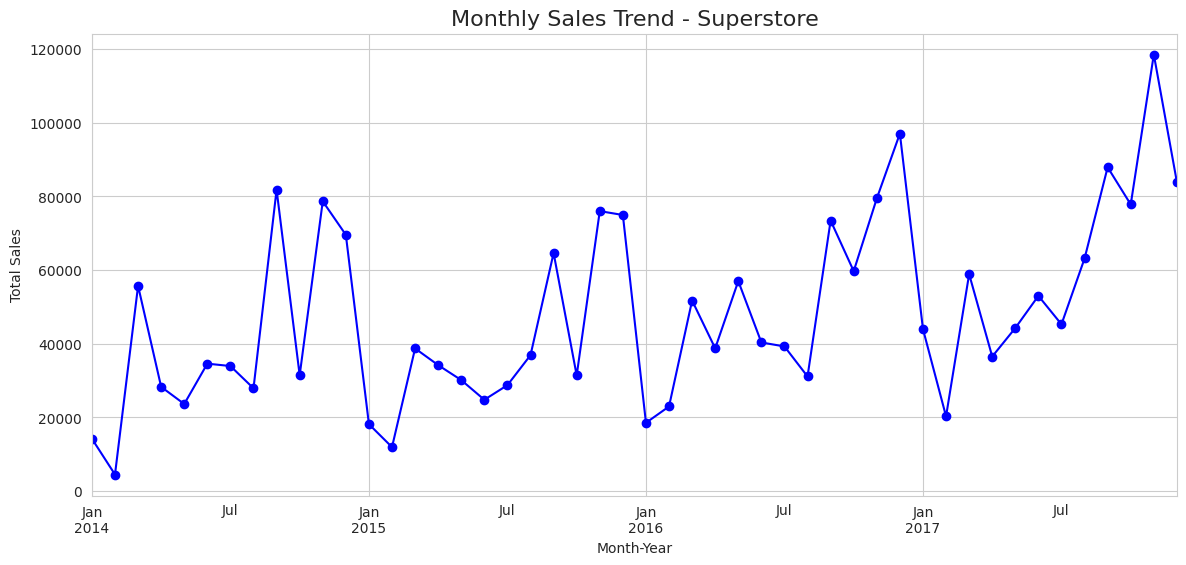

In [ ]:
# Step 5: EDA - Monthly Sales Trend
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot(kind='line', marker='o', color='blue')
plt.title('Monthly Sales Trend - Superstore', fontsize=16)
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

/tmp/ipykernel_933/2406482959.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')


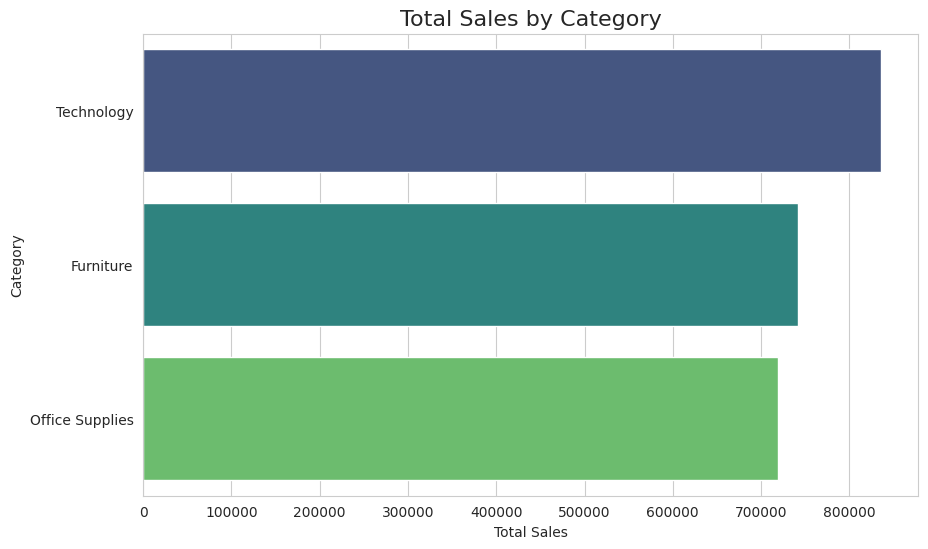

Category-wise Sales:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [ ]:
# Step 6: Category & Sub-Category Analysis
plt.figure(figsize=(10, 6))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')
plt.title('Total Sales by Category', fontsize=16)
plt.xlabel('Total Sales')
plt.ylabel('Category')
plt.show()

print("Category-wise Sales:")
print(category_sales)

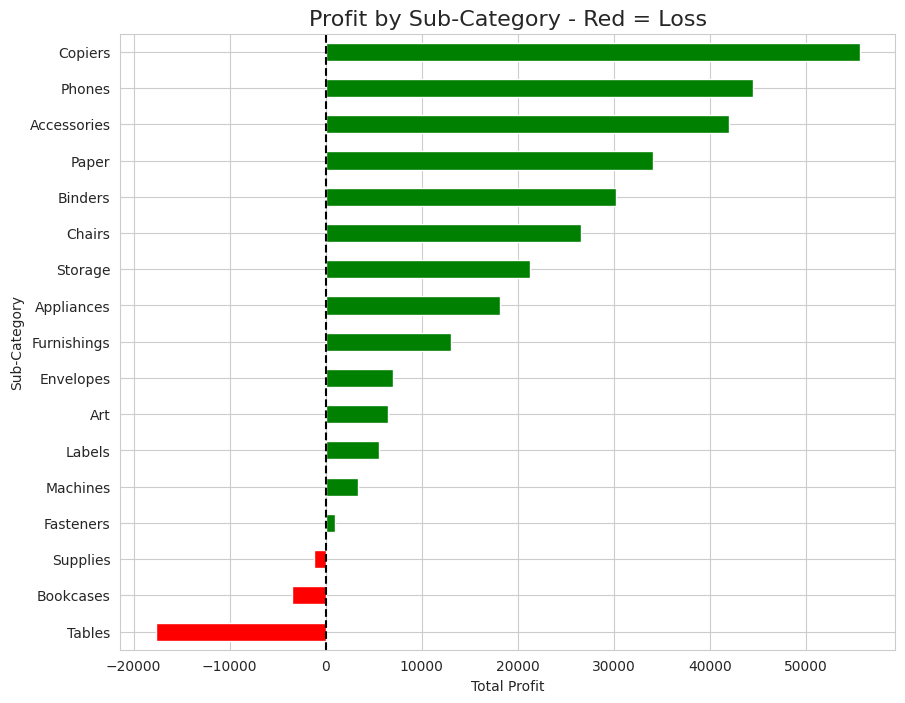

Sub-Categories with Loss:
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


In [ ]:
# Step 7: Profit by Category & Sub-Category
plt.figure(figsize=(12, 6))
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

# Red for loss, Green for profit
colors = ['red' if x < 0 else 'green' for x in subcat_profit.values]

subcat_profit.plot(kind='barh', color=colors, figsize=(10, 8))
plt.title('Profit by Sub-Category - Red = Loss', fontsize=16)
plt.xlabel('Total Profit')
plt.axvline(x=0, color='black', linestyle='--') # Zero line
plt.show()

print("Sub-Categories with Loss:")
print(subcat_profit[subcat_profit < 0])

--- Top 10 Products by Sales ---
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

--- Top 10 Customers by Sales ---
C

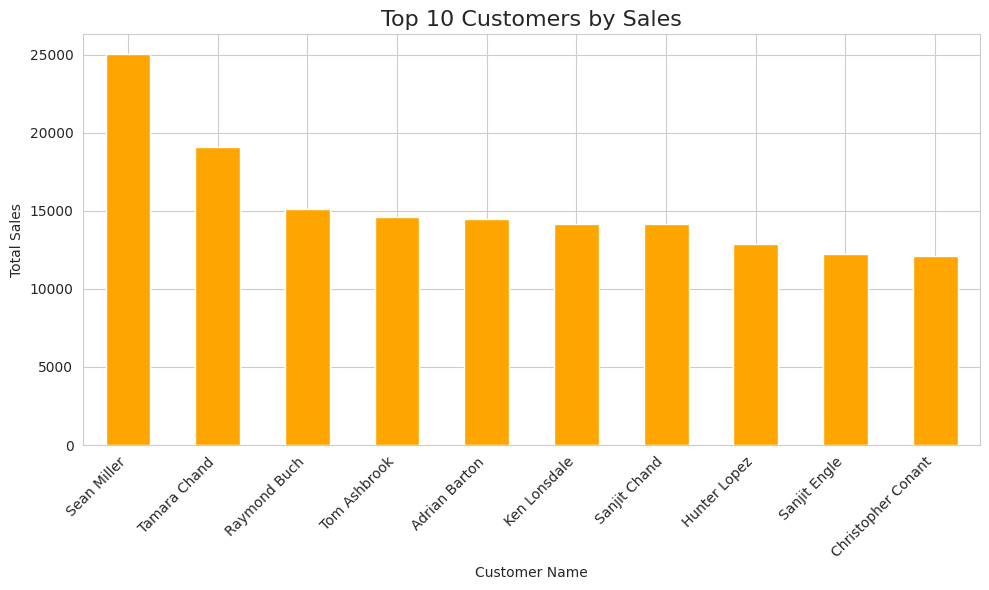

In [ ]:
# Step 8: Top Products & Customers
print("--- Top 10 Products by Sales ---")
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

print("\n--- Top 10 Customers by Sales ---")
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

# Plot Top Customers
plt.figure(figsize=(10, 6))
top_customers.plot(kind='bar', color='orange')
plt.title('Top 10 Customers by Sales', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

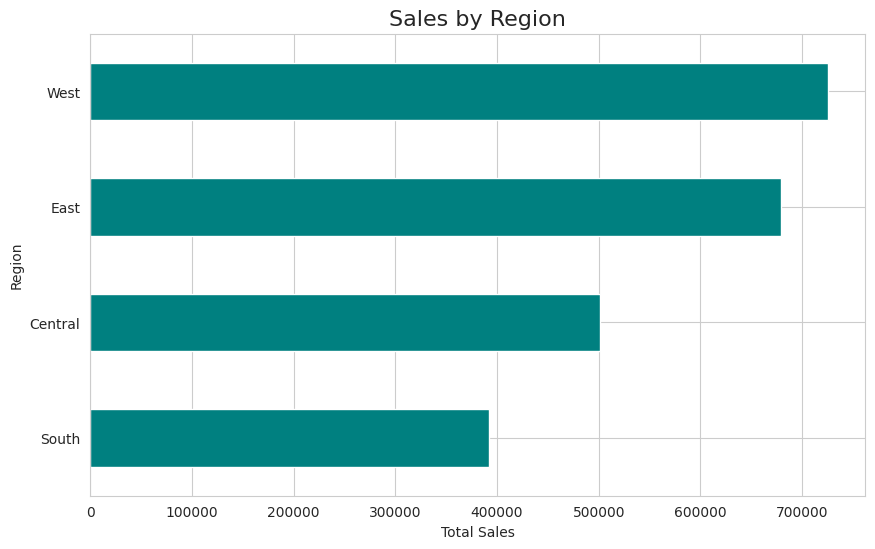

Region-wise Sales:
Region
South      391721.9050
Central    501239.8908
East       678781.2400
West       725457.8245
Name: Sales, dtype: float64

--- Top 10 States by Sales ---
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


In [ ]:
# Step 9: Region & State Analysis
plt.figure(figsize=(10, 6))
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
region_sales.plot(kind='barh', color='teal')
plt.title('Sales by Region', fontsize=16)
plt.xlabel('Total Sales')
plt.show()

print("Region-wise Sales:")
print(region_sales)

print("\n--- Top 10 States by Sales ---")
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
print(state_sales)

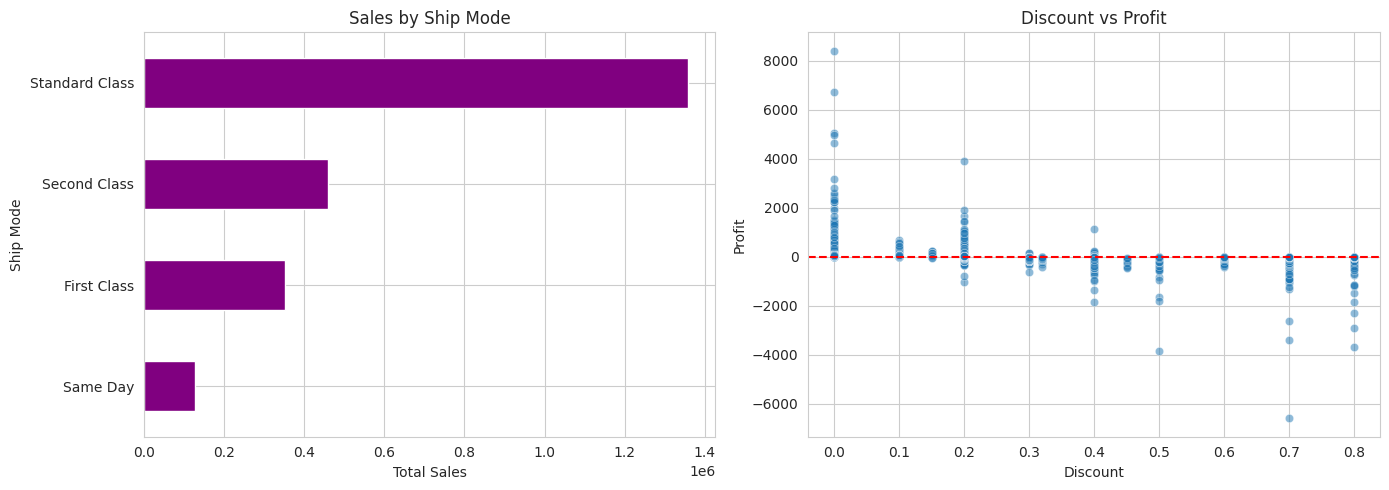

Average Discount where Profit is Negative: 0.48088722608230894


In [ ]:
# Step 10: Shipping & Discount Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Sales by Ship Mode
ship_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values()
ship_sales.plot(kind='barh', ax=axes[0], color='purple')
axes[0].set_title('Sales by Ship Mode')
axes[0].set_xlabel('Total Sales')

# 2. Discount vs Profit
sns.scatterplot(data=df, x='Discount', y='Profit', ax=axes[1], alpha=0.5)
axes[1].set_title('Discount vs Profit')
axes[1].axhline(y=0, color='red', linestyle='--') # Loss line

plt.tight_layout()
plt.show()

print("Average Discount where Profit is Negative:", df[df['Profit'] < 0]['Discount'].mean())

In [ ]:
# Step 11: Final Key Insights Summary
print("--- SUPERSTORE DATASET KEY INSIGHTS ---")

print("\n1. Overall Numbers:")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Total Orders: {df['Order ID'].nunique()}")

print("\n2. Best Performing:")
print(f"Top Category: {df.groupby('Category')['Sales'].sum().idxmax()}")
print(f"Top Region: {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"Top State: {df.groupby('State')['Sales'].sum().idxmax()}")
print(f"Top Customer: {df.groupby('Customer Name')['Sales'].sum().idxmax()}")

print("\n3. Loss Making Areas:")
loss_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(3)
print("Top 3 Loss Sub-Categories:\n", loss_subcat[loss_subcat < 0])

print("\n4. Problem Areas:")
print(f"South Region Sales are Lowest: ${df[df['Region']=='South']['Sales'].sum():,.2f}")
print(f"Orders with Loss: {len(df[df['Profit'] < 0])} out of {len(df)}")

--- SUPERSTORE DATASET KEY INSIGHTS ---

1. Overall Numbers:
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009

2. Best Performing:
Top Category: Technology
Top Region: West
Top State: California
Top Customer: Sean Miller

3. Loss Making Areas:
Top 3 Loss Sub-Categories:
 Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64

4. Problem Areas:
South Region Sales are Lowest: $391,721.91
Orders with Loss: 1871 out of 9994


In [ ]:
    # Clean file banavun download sathi ready kar
    df.to_csv('Superstore_Cleaned.csv', index=False)
    print("File 'Superstore_Cleaned.csv' ready zali ✅")

File 'Superstore_Cleaned.csv' ready zali ✅
